In [1]:
from statistics import linear_regression
!pip install scikit-learn


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('../datasets/streeteasy/manhattan.csv')
df.head()
df.describe()

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym
count,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000
mean,5332.589997,5138.940379,1.351936,1.366770,939.727324,4.970896,11.908307,51.994914,0.403504,0.154846,0.160215,0.281153,0.294716,0.185646,0.055100,0.174908
std,3311.552136,3162.824760,0.967595,0.599588,477.949074,5.513589,10.960893,39.380433,0.490669,0.361809,0.366857,0.449625,0.455979,0.388875,0.228208,0.379942
min,1.000000,1300.000000,0.000000,0.000000,250.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2443.500000,3150.000000,1.000000,1.000000,613.000000,2.000000,4.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5128.000000,4000.000000,1.000000,1.000000,800.000000,4.000000,8.000000,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8149.500000,6000.000000,2.000000,2.000000,1141.000000,6.000000,17.000000,90.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,11349.000000,20000.000000,5.000000,5.000000,4800.000000,43.000000,83.000000,180.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.columns


Index(['rental_id', 'rent', 'bedrooms', 'bathrooms', 'size_sqft',
       'min_to_subway', 'floor', 'building_age_yrs', 'no_fee', 'has_roofdeck',
       'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher',
       'has_patio', 'has_gym', 'neighborhood', 'borough'],
      dtype='str')

In [6]:
x = df[['bedrooms', 'bathrooms', 'size_sqft',
       'min_to_subway', 'floor', 'building_age_yrs', 'no_fee', 'has_roofdeck',
       'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher',
       'has_patio', 'has_gym']]
y = df[['rent']]
x.shape, y.shape


((3539, 14), (3539, 1))

In [9]:
# train 8 : test 2
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=1)
x_train.shape, x_test.shape

((2831, 14), (708, 14))

In [11]:
model = LinearRegression()
model.fit(x_train, y_train)
print(model.coef_)#기울기
print(model.intercept_) #절편

[[-342.56456635 1226.30899358    4.96805511  -20.58752243   22.13733123
    -7.65263855 -158.14431246   21.68897631  131.38735415  -99.55286154
    82.80764887  -19.44543336 -102.6077042   -23.51385096]]
[-440.91279311]


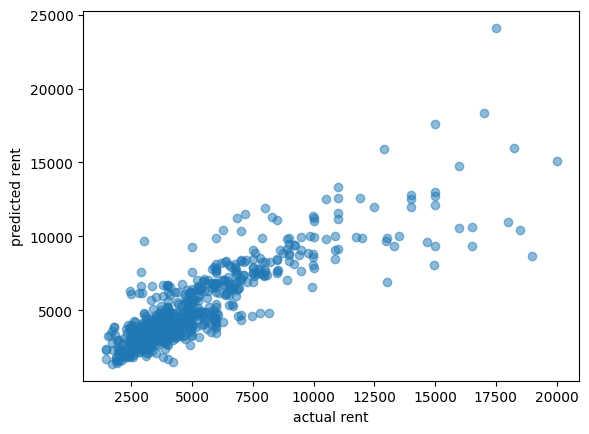

In [13]:
y_hat = model.predict(x_test)
plt.scatter(y_test, y_hat, alpha=0.5)
plt.xlabel('actual rent')
plt.ylabel('predicted rent')
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)
print('r^2 score', r2) # 결정계수 r^2 는 목표변수의 분산을 얼마나 잘설명하는지 나타내는 지표
print('mse error', mse)

r^2 score 0.7467332043233916
mse error 2184500.5863717385


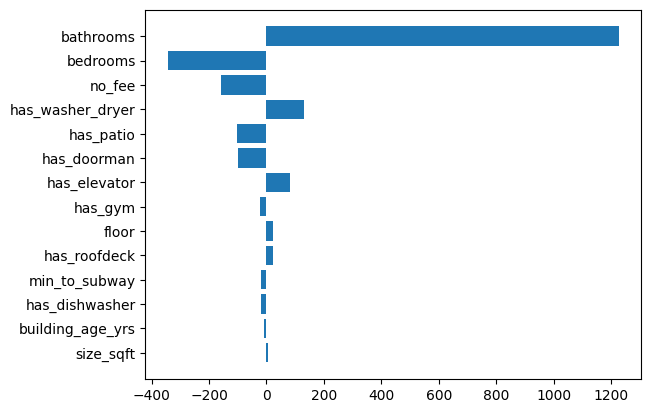

In [17]:
coef_df = pd.DataFrame({'feature':x.columns,'coefficient':model.coef_[0]})
coef_df['abs=coaf'] = coef_df['coefficient'].abs()
coef_sorted = coef_df.sort_values(by='abs=coaf', ascending=False)
plt.figure()
plt.barh(coef_sorted['feature'], coef_sorted['coefficient'])
plt.gca().invert_yaxis()
plt.show()

In [18]:
import numpy as np
num_samples = 5
random_idx = np.random.choice(x_test.index, size=num_samples, replace=False)
x_sample = x_test.loc[random_idx]
y_sample_actual = y_test.loc[random_idx]
print(x_sample.iloc[0])
y_sample_pred = model.predict(x_sample)
for i in range(num_samples):
    print(f'샘플 {i+1}')
    print(f'실제:{y_sample_actual.iloc[i].values[0]}')
    print(f'예측:{y_sample_pred[i]}')

bedrooms              0.0
bathrooms             1.0
size_sqft           666.0
min_to_subway         2.0
floor                 2.0
building_age_yrs     89.0
no_fee                0.0
has_roofdeck          0.0
has_washer_dryer      0.0
has_doorman           1.0
has_elevator          1.0
has_dishwasher        1.0
has_patio             0.0
has_gym               0.0
Name: 1236, dtype: float64
샘플 1
실제:4450
예측:[3379.94504362]
샘플 2
실제:3600
예측:[3816.67131386]
샘플 3
실제:8100
예측:[7399.8357215]
샘플 4
실제:16500
예측:[10636.64947698]
샘플 5
실제:3900
예측:[3482.5715751]


In [20]:
import pickle
# 파이썬 객체를 직렬화 하고 역직렬화하는데 사용되는 라이브러리 (바이너리 형식으로 저장)
with open('manhattan.pkl', 'wb') as f:
    pickle.dump(model, f)
print('model savel')

model savel
